# Import Library

In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns 
from sklearn.model_selection import train_test_split 
from sklearn.preprocessing import LabelEncoder, StandardScaler 
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Load Dataset

In [24]:
df = pd.read_csv('heart.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


# Exploratory Data Analysis

In [25]:
df.tail()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
913,45,M,TA,110,264,0,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130,236,0,LVH,174,N,0.0,Flat,1
917,38,M,NAP,138,175,0,Normal,173,N,0.0,Up,0


In [26]:
df.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

In [27]:
df.duplicated().sum()

0

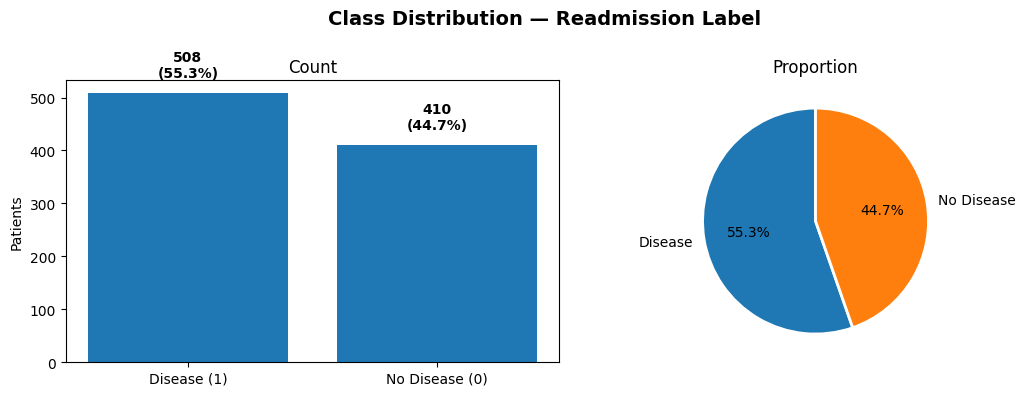

In [28]:
%matplotlib inline
counts = df["HeartDisease"].value_counts()
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
fig.suptitle("Class Distribution — Readmission Label", fontsize=14, fontweight="bold")

axes[0].bar(["Disease (1)", "No Disease (0)"], counts.values, linewidth=1.5)
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 30, f"{v:,}\n({v/len(df)*100:.1f}%)", ha="center",
                 fontsize=10, fontweight="bold")
axes[0].set_title("Count")
axes[0].set_ylabel("Patients")

axes[1].pie(counts.values, labels=["Disease", "No Disease"], autopct="%1.1f%%",
            startangle=90, wedgeprops={"edgecolor": "white", "linewidth": 2})
axes[1].set_title("Proportion")
plt.tight_layout()
plt.show()

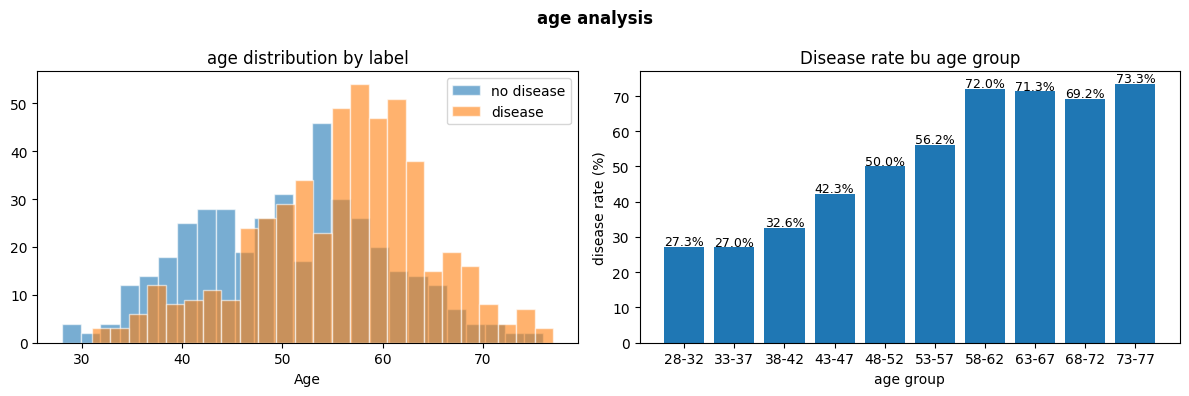

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('age analysis', fontsize=12, fontweight='bold')

for lbl, name in [(0, 'no disease'), (1, 'disease')]:
    axes[0].hist(df[df['HeartDisease']==lbl]['Age'],
                 bins=25, alpha=0.6,
    label=name, edgecolor='white')
axes[0].set_title('age distribution by label')
axes[0].set_xlabel("Age"); axes[0].legend()

age_bins = pd.cut(df["Age"], bins=[28,32,37,42,47,52,57,62,67,72,77],
                                   labels=["28-32", "33-37", "38-42", "43-47", "48-52", "53-57", "58-62", "63-67", "68-72", "73-77"]) 
rate = df.groupby(age_bins, observed=True)["HeartDisease"].mean()*100

axes[1].bar(rate.index, rate.values)
axes[1].set_title('Disease rate bu age group')
axes[1].set_xlabel("age group"); axes[1].set_ylabel('disease rate (%)')
for i, v in enumerate(rate.values):
    axes[1].text(i, v+0.5, f"{v:.1f}%", ha="center", fontsize=9)
plt.tight_layout()
plt.show()

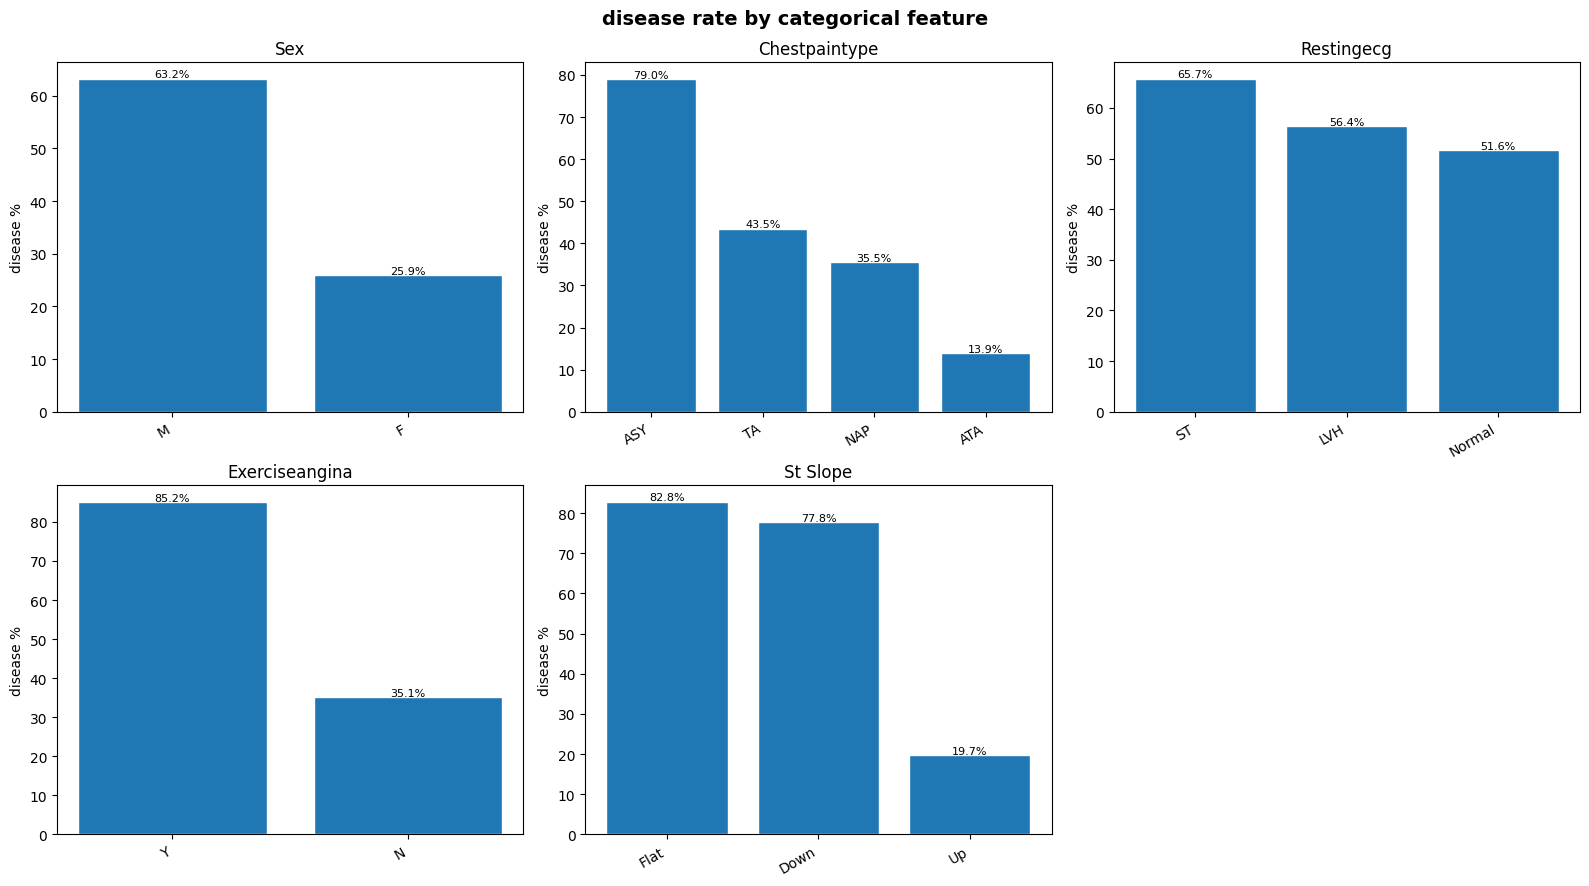

In [30]:
categorical_cols = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle("disease rate by categorical feature", fontsize=14, fontweight='bold')
axes = axes.flatten()

for idx, col in enumerate(categorical_cols):
    rate = df.groupby(col)['HeartDisease'].mean().sort_values(ascending=False) * 100 
    bars = axes[idx].bar(range(len(rate)), rate.values, edgecolor='white')
    axes[idx].set_xticks(range(len(rate)))
    axes[idx].set_xticklabels(rate.index, rotation=30, ha='right')
    axes[idx].set_title(col.replace("_", " ").title())
    axes[idx].set_ylabel('disease %')
    for bar, val in zip(bars, rate.values):
        axes[idx].text(bar.get_x() + bar.get_width()/2, val+0.3,
                       f"{val:.1f}%", ha='center', fontsize=8)
axes[5].set_visible(False)
plt.tight_layout()

IndexError: index 4 is out of bounds for axis 1 with size 4

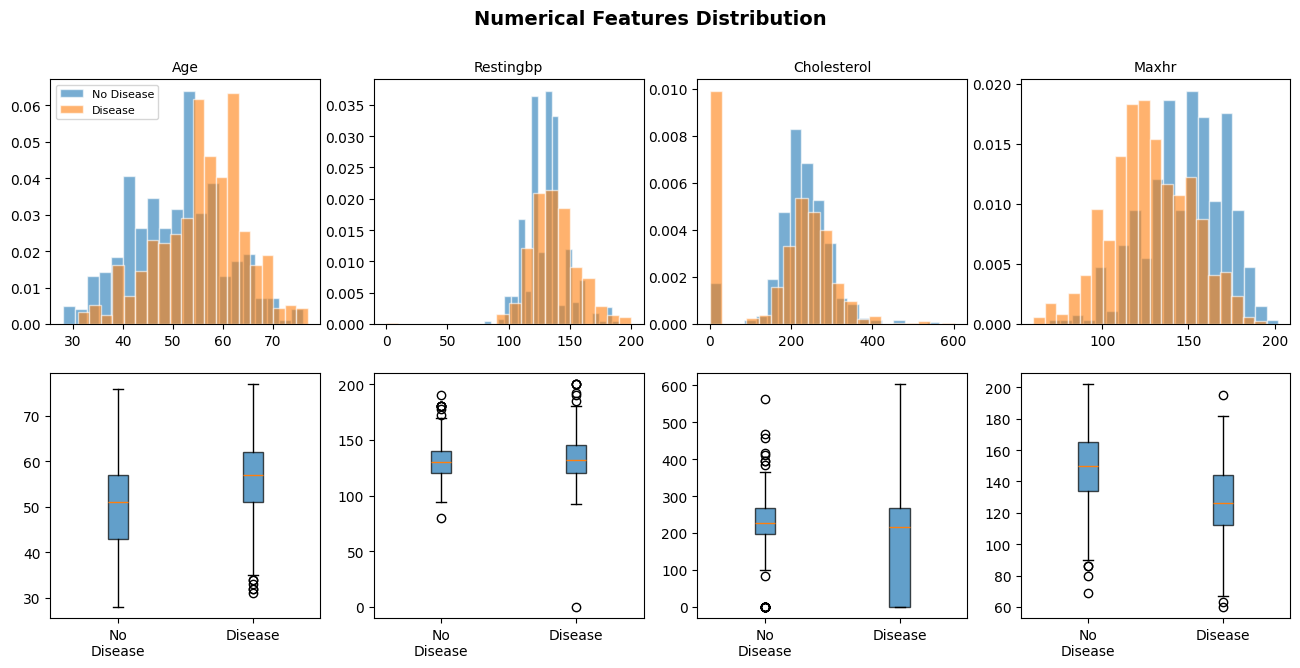

In [31]:
num_cols = ["Age", "RestingBP", "Cholesterol", "MaxHR",
            "FastingBS", "Oldpeak"]

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
fig.suptitle("Numerical Features Distribution", fontsize=14, fontweight="bold")

for i, col in enumerate(num_cols):

    # Histogram
    for lbl, name in [(0, "No Disease"), (1, "Disease")]:
        subset = df[df["HeartDisease"] == lbl][col]
        axes[0, i].hist(subset, bins=20, alpha=0.6,
                        label=name, density=True, edgecolor="white")

    axes[0, i].set_title(col.replace("_", " ").title(), fontsize=10)

    if i == 0:
        axes[0, i].legend(fontsize=8)

    # Boxplot
    data_0 = df[df["HeartDisease"] == 0][col]
    data_1 = df[df["HeartDisease"] == 1][col]

    bp = axes[1, i].boxplot([data_0, data_1],
                            patch_artist=True,
                            labels=["No\nDisease", "Disease"])

    for patch in bp["boxes"]:
        patch.set_alpha(0.7)

plt.tight_layout()
plt.show()

# Data Preprocessing

computing correlation matrix


<function matplotlib.pyplot.show(close=None, block=None)>

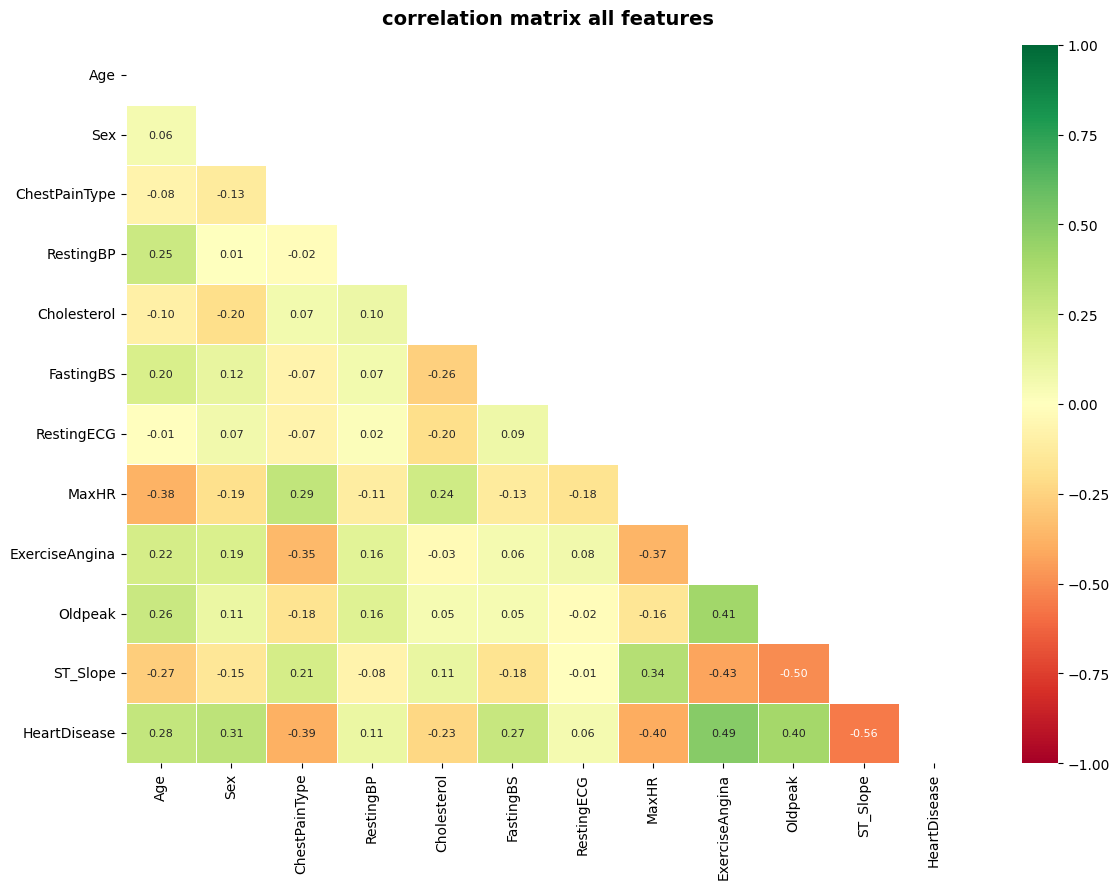

In [ ]:
print('computing correlation matrix')
df_enc = df.copy()
le = LabelEncoder()

for col in ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']:
    df_enc[col] = le.fit_transform(df_enc[col].astype(str))

corr = df_enc.corr()
fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap='RdYlGn',
            center=0, vmin=-1, vmax=1, ax=ax, linewidths=0.5, linecolor='white',
            annot_kws={"size": 8})

ax.set_title("correlation matrix all features", fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show

In [ ]:
scaler = StandardScaler()
X = df_enc.drop('HeartDisease', axis=1)
y = df_enc['HeartDisease']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('data after scaling:')
print(X_train_scaled.shape, X_test_scaled.shape)

data after scaling:
(734, 11) (184, 11)


# Build Model & Train & Evaluation

In [ ]:
model = RandomForestClassifier(n_estimators=100, random_state=42)

model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.86      0.86      0.86        77
           1       0.90      0.90      0.90       107

    accuracy                           0.88       184
   macro avg       0.88      0.88      0.88       184
weighted avg       0.88      0.88      0.88       184



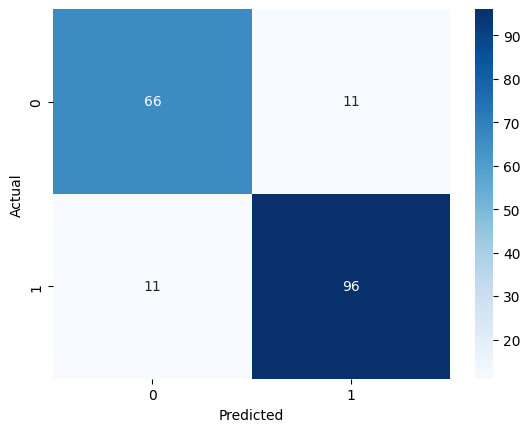

In [ ]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [ ]:
model2 = GradientBoostingClassifier(n_estimators=100, random_state=42)
model2.fit(X_train_scaled, y_train)
y_pred = model2.predict(X_test_scaled)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.82      0.90      0.86        77
           1       0.92      0.86      0.89       107

    accuracy                           0.88       184
   macro avg       0.87      0.88      0.87       184
weighted avg       0.88      0.88      0.88       184



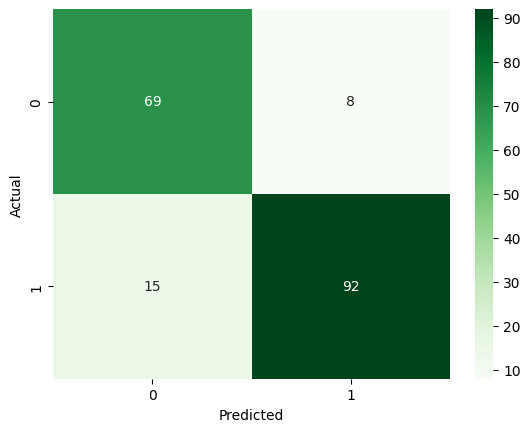

In [ ]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Inference with New Data

In [ ]:
# Create a new sample for inference
new_patient = pd.DataFrame({
    'Age': [55],
    'Sex': [1],  # 1 for Male, 0 for Female
    'ChestPainType': [0],
    'RestingBP': [130],
    'Cholesterol': [250],
    'FastingBS': [0],
    'RestingECG': [1],
    'MaxHR': [140],
    'ExerciseAngina': [0],
    'Oldpeak': [1.5],
    'ST_Slope': [1]
})

# Scale the new data
new_patient_scaled = scaler.transform(new_patient)

# Make predictions with both models
rf_prediction = model.predict(new_patient_scaled)[0]
rf_probability = model.predict_proba(new_patient_scaled)[0]

gb_prediction = model2.predict(new_patient_scaled)[0]
gb_probability = model2.predict_proba(new_patient_scaled)[0]

# Display results
print("=" * 50)
print("HEART DISEASE INFERENCE - NEW PATIENT")
print("=" * 50)
print("\nPatient Data:")
print(new_patient)
print("\n--- Random Forest Model ---")
print(f"Prediction: {'Disease (1)' if rf_prediction == 1 else 'No Disease (0)'}")
print(f"Probability - No Disease: {rf_probability[0]:.4f}")
print(f"Probability - Disease: {rf_probability[1]:.4f}")

print("\n--- Gradient Boosting Model ---")
print(f"Prediction: {'Disease (1)' if gb_prediction == 1 else 'No Disease (0)'}")
print(f"Probability - No Disease: {gb_probability[0]:.4f}")
print(f"Probability - Disease: {gb_probability[1]:.4f}")

print("\n" + "=" * 50)

HEART DISEASE INFERENCE - NEW PATIENT

Patient Data:
   Age  Sex  ChestPainType  RestingBP  Cholesterol  FastingBS  RestingECG  \
0   55    1              0        130          250          0           1   

   MaxHR  ExerciseAngina  Oldpeak  ST_Slope  
0    140               0      1.5         1  

--- Random Forest Model ---
Prediction: Disease (1)
Probability - No Disease: 0.1900
Probability - Disease: 0.8100

--- Gradient Boosting Model ---
Prediction: Disease (1)
Probability - No Disease: 0.2334
Probability - Disease: 0.7666



# Dashboard for the Model Prediction

In [ ]:
import gradio as gr

def predict_heart_disease(age, sex, chest_pain, resting_bp, cholesterol, fasting_bs, resting_ecg, max_hr, exercise_angina, oldpeak, st_slope):
    """
    Predict heart disease using both Random Forest and Gradient Boosting models
    """
    # Create input dataframe
    input_data = pd.DataFrame({
        'Age': [age],
        'Sex': [sex],
        'ChestPainType': [chest_pain],
        'RestingBP': [resting_bp],
        'Cholesterol': [cholesterol],
        'FastingBS': [fasting_bs],
        'RestingECG': [resting_ecg],
        'MaxHR': [max_hr],
        'ExerciseAngina': [exercise_angina],
        'Oldpeak': [oldpeak],
        'ST_Slope': [st_slope]
    })
    
    # Scale the input
    input_scaled = scaler.transform(input_data)
    
    # Predictions from both models
    rf_pred = model.predict(input_scaled)[0]
    rf_prob = model.predict_proba(input_scaled)[0]
    
    gb_pred = model2.predict(input_scaled)[0]
    gb_prob = model2.predict_proba(input_scaled)[0]
    
    # Prepare output
    result = f"""
    <div style="font-family: Arial; padding: 20px;">
    <h2>🏥 Heart Disease Prediction Results</h2>
    
    <h3>📊 Random Forest Model</h3>
    <p><b>Prediction:</b> {'❌ Disease (High Risk)' if rf_pred == 1 else '✅ No Disease (Low Risk)'}</p>
    <p><b>No Disease Probability:</b> {rf_prob[0]:.2%}</p>
    <p><b>Disease Probability:</b> {rf_prob[1]:.2%}</p>
    
    <h3>📊 Gradient Boosting Model</h3>
    <p><b>Prediction:</b> {'❌ Disease (High Risk)' if gb_pred == 1 else '✅ No Disease (Low Risk)'}</p>
    <p><b>No Disease Probability:</b> {gb_prob[0]:.2%}</p>
    <p><b>Disease Probability:</b> {gb_prob[1]:.2%}</p>
    
    <h3>📌 Summary</h3>
    <p>Both models {'agree on disease risk' if rf_pred == gb_pred else 'disagree on prediction'}.</p>
    </div>
    """
    
    return result

# Create Gradio interface
with gr.Blocks(title="Heart Disease Prediction Dashboard", theme=gr.themes.Soft()) as demo:
    gr.Markdown("# 🏥 Heart Disease Prediction Dashboard")
    gr.Markdown("Enter patient information to predict heart disease risk using ML models")
    
    with gr.Row():
        with gr.Column():
            gr.Markdown("### Patient Information")
            age = gr.Slider(minimum=28, maximum=77, value=55, label="Age", step=1)
            sex = gr.Radio(choices=[0, 1], value=1, label="Sex (0=Female, 1=Male)")
            chest_pain = gr.Slider(minimum=0, maximum=3, value=0, label="Chest Pain Type", step=1)
            resting_bp = gr.Slider(minimum=80, maximum=200, value=130, label="Resting BP", step=1)
            cholesterol = gr.Slider(minimum=0, maximum=603, value=250, label="Cholesterol", step=1)
        
        with gr.Column():
            gr.Markdown("### More Information")
            fasting_bs = gr.Radio(choices=[0, 1], value=0, label="Fasting BS (0=<120, 1=>120)")
            resting_ecg = gr.Slider(minimum=0, maximum=2, value=1, label="Resting ECG", step=1)
            max_hr = gr.Slider(minimum=60, maximum=202, value=140, label="Max HR", step=1)
            exercise_angina = gr.Radio(choices=[0, 1], value=0, label="Exercise Angina (0=No, 1=Yes)")
            oldpeak = gr.Slider(minimum=0, maximum=6.2, value=1.5, label="Oldpeak", step=0.1)
            st_slope = gr.Slider(minimum=0, maximum=2, value=1, label="ST Slope", step=1)
    
    predict_btn = gr.Button("🔮 Predict", variant="primary", scale=1)
    output = gr.HTML()
    
    predict_btn.click(
        fn=predict_heart_disease,
        inputs=[age, sex, chest_pain, resting_bp, cholesterol, fasting_bs, resting_ecg, max_hr, exercise_angina, oldpeak, st_slope],
        outputs=output
    )

demo.launch()

* Running on local URL:  http://127.0.0.1:7860

To create a public link, set `share=True` in `launch()`.
